In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
## Geometric Brownian motion
# S(t) = S0 * exp((mu - 0.5 * sigma^2)*dt + sigma*sqrt(dt) * Z)

In [3]:
# GBM simulator
def simulate_gbm(S0, mu, sigma, T, N):
    dt = T / N                                  # incremental time difference, on which we are calculating the price
    t = np.linspace(0, T, N)                    # time array (X-axis)
    W = np.random.standard_normal(size=N)       # normal distribution between time 0 to time T
    W = np.cumsum(W) * np.sqrt(dt)              # Standard Brownian motion
    X = (mu - 0.5 * sigma**2) * t + sigma * W   
    S = S0 * np.exp(X)
    return S

In [4]:
#defining initial parameters
S0 = 100      # Initial stock price
mu = 0.05     # Drift
sigma = 0.20  # Volatility
T = 1         # Time horizon (years)
N = 252       # Number of days

In [5]:
def PlotSimulatedPaths(paths, S0, mu, T):
    N = paths.shape[1]
    t_axis = np.linspace(0, T, N)
    expected_path = S0 * np.exp(mu * t_axis)   # E[S(t)] = S0 * exp(mu*t)

    plt.figure(figsize=(12, 10))
    plt.plot(paths.T, alpha=0.3, linewidth=0.8)
    plt.plot(expected_path, color='black', linewidth=2.5, label='E[S(t)] = S0·exp(μt)')
    plt.title('Geometric Brownian Motion')
    plt.xlabel('no. of trading days or time steps')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

In [6]:
def RunSimulationEngine(sim_runs, S0, mu, sigma, T, N):
    paths = np.zeros((sim_runs, N))
    for i in range(sim_runs):
        paths[i] = simulate_gbm(S0, mu, sigma, T, N)
    return paths

In [7]:
def GetTerminalPrices(paths):
    return paths[:, -1]

In [8]:
def PlotTerminalPrices(prices):
    plt.figure(figsize = (10, 6))
    plt.hist(prices)
    plt.title('Terminal prices of GBM Paths')
    plt.xlabel('Price')
    plt.ylabel('Frequency')

    plt.show()

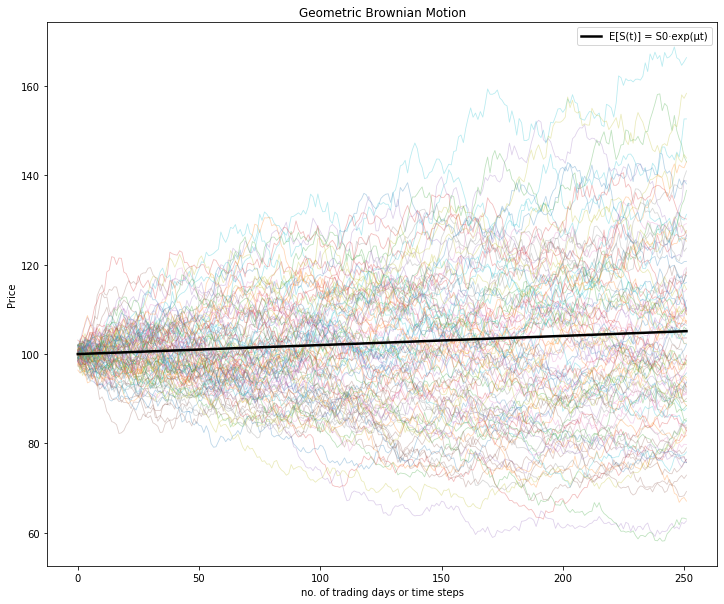

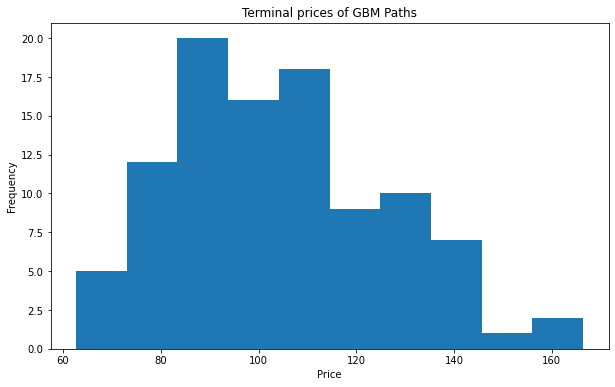

Terminal stats  —  Mean: 104.12  |  Std: 21.58  |  Analytical E[S(T)]: 105.13


In [9]:
#for 100 simulation runs
simulatedPaths = RunSimulationEngine(100, S0, mu, sigma, T, N)
PlotSimulatedPaths(simulatedPaths, S0, mu, T)
terminalPrices = GetTerminalPrices(simulatedPaths)
PlotTerminalPrices(terminalPrices)
print(f"Terminal stats  —  Mean: {terminalPrices.mean():.2f}  |  "
      f"Std: {terminalPrices.std():.2f}  |  "
      f"Analytical E[S(T)]: {S0 * np.exp(mu * T):.2f}")

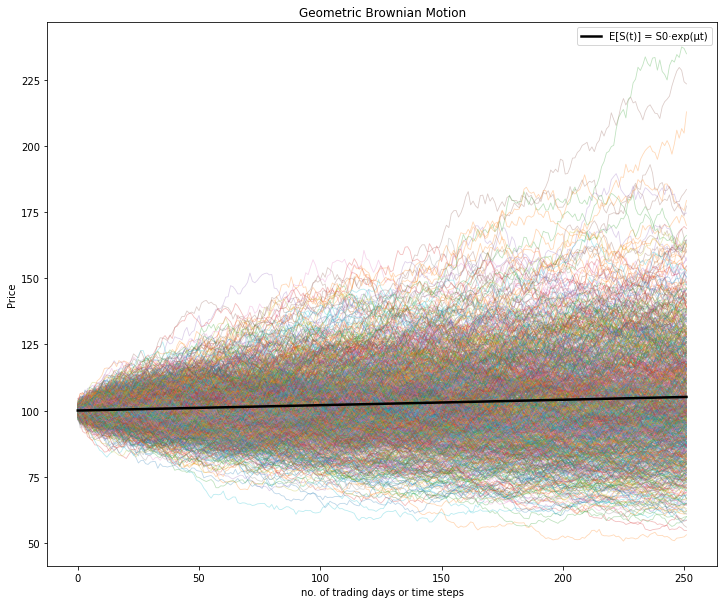

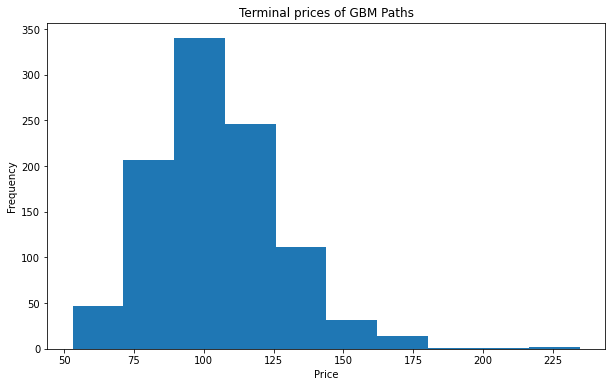

Terminal stats  —  Mean: 104.64  |  Std: 22.65  |  Analytical E[S(T)]: 105.13


In [10]:
#for 1000 simulation runs
simulatedPaths = RunSimulationEngine(1000, S0, mu, sigma, T, N)
PlotSimulatedPaths(simulatedPaths, S0, mu, T)
terminalPrices = GetTerminalPrices(simulatedPaths)
PlotTerminalPrices(terminalPrices)
print(f"Terminal stats  —  Mean: {terminalPrices.mean():.2f}  |  "
      f"Std: {terminalPrices.std():.2f}  |  "
      f"Analytical E[S(T)]: {S0 * np.exp(mu * T):.2f}")

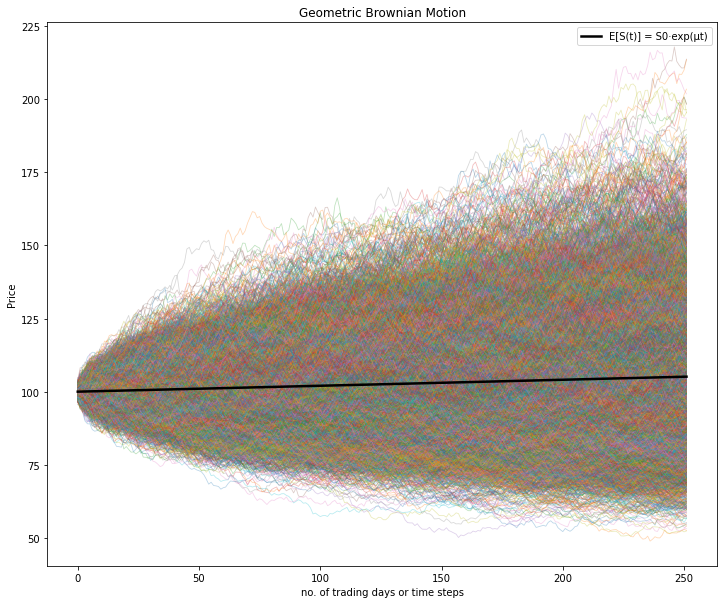

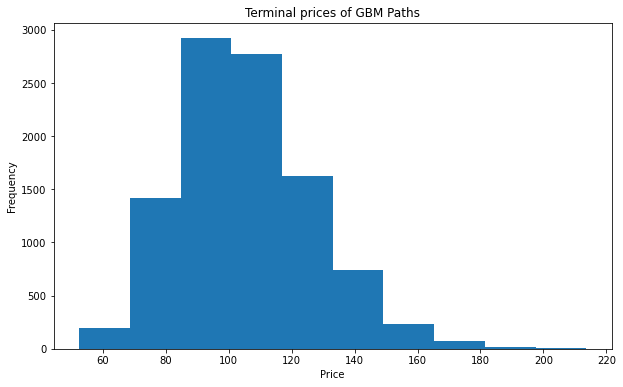

Terminal stats  —  Mean: 105.38  |  Std: 21.44  |  Analytical E[S(T)]: 105.13


In [11]:
#for 10000 simulation runs
simulatedPaths = RunSimulationEngine(10000, S0, mu, sigma, T, N)
PlotSimulatedPaths(simulatedPaths, S0, mu, T)
terminalPrices = GetTerminalPrices(simulatedPaths)
PlotTerminalPrices(terminalPrices)
print(f"Terminal stats  —  Mean: {terminalPrices.mean():.2f}  |  "
      f"Std: {terminalPrices.std():.2f}  |  "
      f"Analytical E[S(T)]: {S0 * np.exp(mu * T):.2f}")